

#EM2050 Computational Methods
##Practical 2



### Lagrange (Barycentric) Interpolation of Air Quality Data

**1. Generate the n + 1 = 5 Chebyshev extrema over [0, 11]**
We need 5 points, so $n = 4$. The interval is $[a, b] = [0, 11]$.
The formula for Chebyshev extrema is:
$t_k = \frac{a+b}{2} + \frac{b-a}{2}\cos\left(\frac{k\pi}{n}\right)$ for $k = 0, 1, 2, 3, 4$.

* $k = 0$: $t_0 = 5.5 + 5.5\cos(0) = 11$
* $k = 1$: $t_1 = 5.5 + 5.5\cos(\pi/4) \approx 9.389$
* $k = 2$: $t_2 = 5.5 + 5.5\cos(2\pi/4) = 5.5$
* $k = 3$: $t_3 = 5.5 + 5.5\cos(3\pi/4) \approx 1.611$
* $k = 4$: $t_4 = 5.5 + 5.5\cos(\pi) = 0$
The 5 ideal extrema are approximately **{0, 1.611, 5.5, 9.389, 11}**.

**2. Determine the closest available measured data point**
We match the ideal points to the closest whole hours in our dataset:
* Ideal $t = 0 \rightarrow$ Closest is $t = 0$
* Ideal $t = 1.611 \rightarrow$ Closest is $t = 2$
* Ideal $t = 5.5 \rightarrow$ Exact tie between 5 and 6. We will use $t = 5$ (first occurrence).
* Ideal $t = 9.389 \rightarrow$ Closest is $t = 9$
* Ideal $t = 11 \rightarrow$ Closest is $t = 11$

**3. Construct the interpolation nodes**
Pairing our selected times with the PM2.5 measurements from the table:
* Node 0: $(0, 18)$
* Node 1: $(2, 19)$
* Node 2: $(5, 30)$
* Node 3: $(9, 22)$
* Node 4: $(11, 19)$

**4. Compute the barycentric weights**
The formula for the barycentric weights $w_j$ is $w_j = \prod_{k \neq j} \frac{1}{x_j - x_k}$.

*Hand computation for $w_0$ (where $x_0 = 0$):*
$w_0 = \frac{1}{(0 - 2)(0 - 5)(0 - 9)(0 - 11)} = \frac{1}{(-2)(-5)(-9)(-11)} = \frac{1}{990} \approx 0.0010101$

*Remaining Weights:*
* $w_1 = \frac{1}{(2 - 0)(2 - 5)(2 - 9)(2 - 11)} = \frac{1}{-378} \approx -0.0026455$
* $w_2 = \frac{1}{(5 - 0)(5 - 2)(5 - 9)(5 - 11)} = \frac{1}{360} \approx 0.0027778$
* $w_3 = \frac{1}{(9 - 0)(9 - 2)(9 - 5)(9 - 11)} = \frac{1}{-504} \approx -0.0019841$
* $w_4 = \frac{1}{(11 - 0)(11 - 2)(11 - 5)(11 - 9)} = \frac{1}{(11)(9)(6)(2)} = \frac{1}{1188} \approx 0.0008418$

In [13]:
import numpy as np


t_data = np.arange(12)
f_data = np.array([18, 20, 19, 23, 27, 30, 28, 25, 24, 22, 20, 19])


n = 4
a, b = 0, 11
k = np.arange(n + 1)
cheb_extrema = 0.5 * (a + b) + 0.5 * (b - a) * np.cos(k * np.pi / n)


closest_indices = [np.argmin(np.abs(t_data - target)) for target in cheb_extrema]
closest_indices = np.unique(closest_indices)

x_nodes = t_data[closest_indices]
y_nodes = f_data[closest_indices]

print(f"Selected time nodes (t): {x_nodes}")
print(f"Corresponding PM2.5 (f(t)): {y_nodes}")


weights = np.zeros(len(x_nodes))
for j in range(len(x_nodes)):
    diffs = x_nodes[j] - x_nodes
    diffs = diffs[diffs != 0]
    weights[j] = 1.0 / np.prod(diffs)

print("\nComputed Barycentric Weights:")
for i, w in enumerate(weights):
    print(f"w_{i} = {w:.7f}")

t_target = 3.0


numerator = np.sum((weights / (t_target - x_nodes)) * y_nodes)
denominator = np.sum(weights / (t_target - x_nodes))
pm25_estimate = numerator / denominator

print(f"\nEstimated PM2.5 concentration at t = {t_target} hours is: {pm25_estimate:.2f} µg/m³")

Selected time nodes (t): [ 0  2  5  9 11]
Corresponding PM2.5 (f(t)): [18 19 30 22 19]

Computed Barycentric Weights:
w_0 = 0.0010101
w_1 = -0.0026455
w_2 = 0.0027778
w_3 = -0.0019841
w_4 = 0.0008418

Estimated PM2.5 concentration at t = 3.0 hours is: 23.21 µg/m³


##Task 1

### Task 1: Understanding the Node Selection Procedure

**1. What mathematical points are generated by the function fx(a,b,n)?**
The function generates **Chebyshev extrema** (specifically known as Chebyshev-Gauss-Lobatto nodes) that are mapped and scaled to the specific interval $[a, b]$ of our dataset. The mathematical formula used to generate $n+1$ ideal theoretical nodes over the domain $[a, b]$ is:
$x_k = \frac{1}{2}(a+b) + \frac{1}{2}(b-a)\cos\left(\frac{k\pi}{n}\right)$ for $k = 0, 1, 2, \dots, n$.

**2. Explain why these points are useful for polynomial interpolation.**
They are the mathematical cure for **Runge's Phenomenon**. If we try to build a single high-degree polynomial using evenly spaced data points, the polynomial is forced to stretch too far between points near the boundaries, causing massive mathematical tension that results in extreme, wild spikes at the edges of the timeline.
Chebyshev nodes solve this by distributing the points unevenly—they cluster very tightly near the beginning and end of the dataset and spread out in the middle. By bunching up at the boundaries, they "pin down" the edges of the polynomial, completely preventing those wild swings and keeping the entire curve mathematically stable.

**3. Explain how the interpolation nodes are selected from the available data.**
There is a fundamental clash between pure math and real-world data: the exact theoretical time for a Chebyshev node (e.g., Day 14.382) likely does not have a corresponding sensor reading in our hourly dataset. The code bridges this gap using a "closest match" logic:
* First, it calculates the ideal mathematical timestamps where the nodes *should* be.
* It computes the absolute difference between these ideal times and every single actual recorded timestamp in the dataset using `np.abs()`.
* It uses `np.argmin()` to find the index of the real timestamp that has the smallest difference (e.g., choosing a real reading at Day 14.375 because it is close enough to the ideal Day 14.382).
* Finally, it removes any duplicate indices using `np.unique()`. This ensures the interpolator does not crash by trying to process the exact same coordinate twice.

**4. Describe the overall purpose of the code fragment.**
The overall purpose is to take a massive dataset (8760 hourly readings) and systematically reduce it to a much smaller, mathematically optimal subset of nodes. By calculating where Chebyshev nodes should be and snapping them to the closest real data points, the code prepares a highly stable foundation. This allows us to construct a Barycentric interpolating polynomial that can smoothly and accurately estimate air quality across the entire year without failing.

In [2]:
from google.colab import files
uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))


Saving airdata.npy to airdata.npy
User uploaded file "airdata.npy" with length 70208 bytes


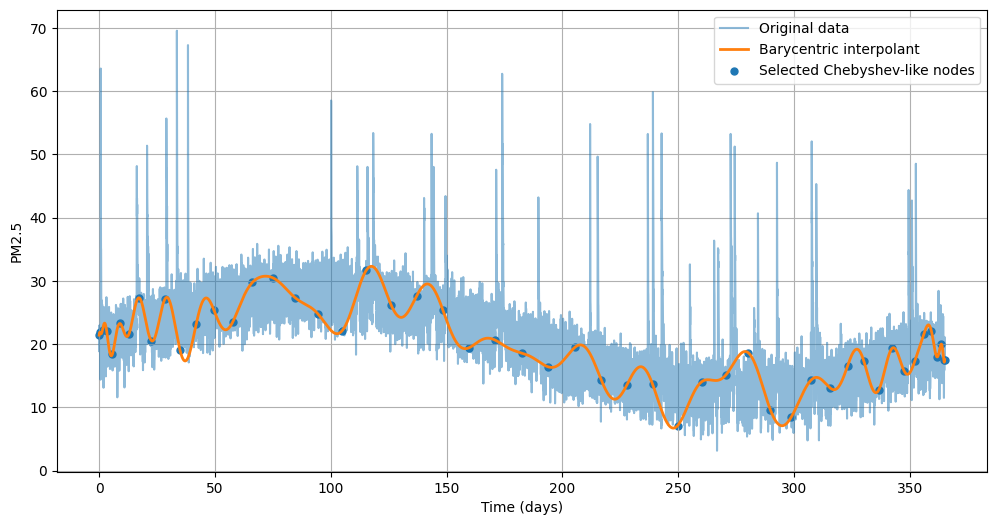

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import BarycentricInterpolator
# Load data
data = np.load("airdata.npy")
# Number of data points
N = len(data)
# Number of interpolation intervals
n = 50
# Chebyshev extrema on [a,b]
fx = lambda a, b, n: 0.5 * (
a + b + (b - a) * np.cos(np.arange(n + 1) * np.pi / n)
)
# Domain in days
a = 0
b = (N - 1) / 24
domain = np.linspace(a, b, N)
# Chebyshev extrema
points = fx(a, b, n)
# Find closest available data points
temp = np.abs(points - domain.reshape(N, 1))
temp2 = np.argmin(temp, axis=0)
# Remove duplicate indices
temp2 = np.unique(temp2)
# Selected nodes
xnodes = domain[temp2]
ynodes = data[temp2]
# Construct barycentric interpolant
poly = BarycentricInterpolator(xnodes, ynodes)
# Evaluate over full domain
yinterp = poly(domain)
# Plot
plt.figure(figsize=(12, 6))
plt.plot(domain, data, label="Original data", alpha=0.5)
plt.plot(domain, yinterp, label="Barycentric interpolant", linewidth=2)
plt.scatter(xnodes, ynodes, s=25, label="Selected Chebyshev-like nodes")
plt.xlabel("Time (days)")
plt.ylabel("PM2.5")
plt.legend()
plt.grid(True)
plt.show()

##Task 2

### Task 2: Comparison of Interpolants at n=50

Based on the generated graphs, comparing Barycentric interpolation using Chebyshev-like nodes versus equally spaced nodes reveals critical differences in stability and accuracy:

* **Interpolation Accuracy:** The Chebyshev-like nodes yield a remarkably smooth, globally accurate approximation of the underlying PM2.5 air quality trend. In stark contrast, the polynomial built on equally spaced nodes fails to track the data accurately. It frequently deviates wildly from the original values in the spaces between the actual node points.
* **Behaviour Near the Endpoints (Runge's Phenomenon):** This is where the methods diverge most drastically. For equally spaced nodes at $n=50$, we clearly observe **Runge's phenomenon**—massive, catastrophic oscillations occurring at the edges of the timeline (the beginning and end of the year). Because the Chebyshev nodes are distributed so that they cluster tightly near the boundaries of the interval, they successfully anchor the curve and entirely suppress these wild endpoint oscillations.
* **Numerical Stability:** Barycentric interpolation relies on calculating a set of mathematical weights based purely on the x-coordinates (time). For Chebyshev nodes, these weights are well-conditioned, meaning the calculation remains highly stable without computer rounding errors, even at high degrees like $n=50$. Conversely, trying to compute weights for equally spaced nodes at high degrees introduces severe mathematical tension and rounding errors, causing the calculation to become completely numerically unstable (which prompts Python to throw RankWarnings).
* **Computational Cost:** The theoretical computational complexity for Barycentric interpolation is identical for both spacing methods: $O(N^2)$ for generating the weights and $O(N)$ for evaluating the polynomial. However, because the equally spaced method produces completely erratic and unusable output at $n=50$ due to instability, its computational cost is entirely wasted. The Chebyshev method delivers a highly robust, usable mathematical model for the exact same amount of computational effort.

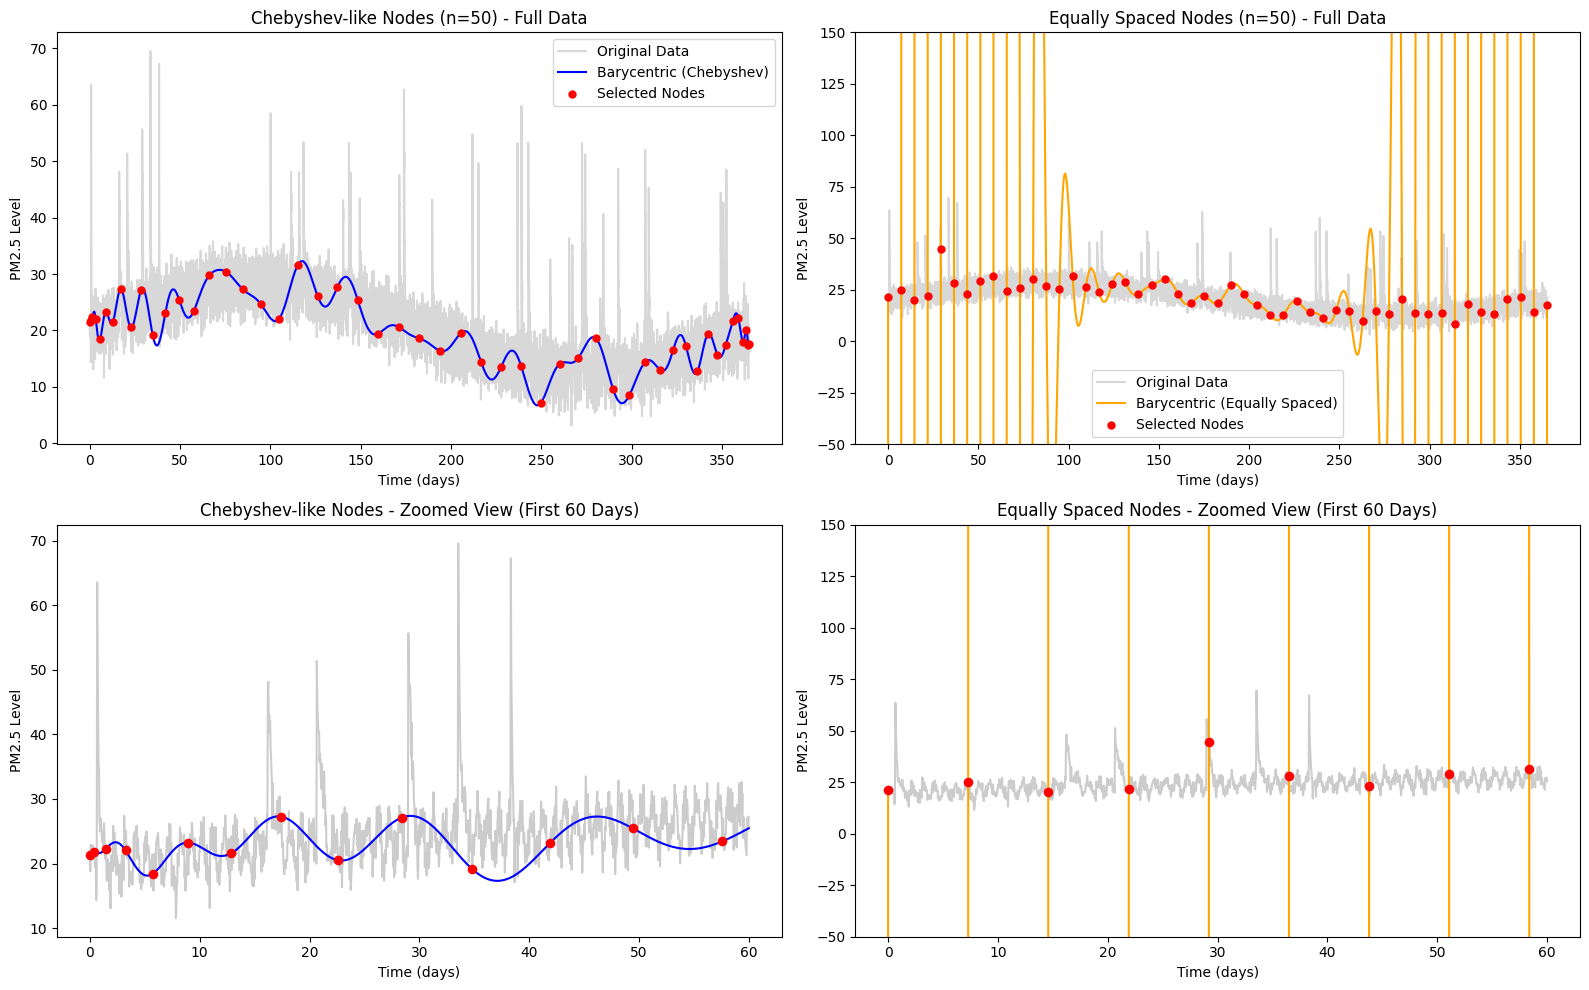

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import BarycentricInterpolator
import warnings
from numpy.polynomial.polyutils import RankWarning


warnings.simplefilter('ignore', RankWarning)


data = np.load("airdata.npy")
N = len(data)

a = 0
b = (N - 1) / 24
domain = np.linspace(a, b, N)

def large_scale_interpolation(n):
    """
    Constructs and compares Barycentric interpolating polynomials using
    Chebyshev-like nodes vs Equally Spaced nodes.
    """

    k = np.arange(n + 1)


    cheb_points = 0.5 * (a + b + (b - a) * np.cos(k * np.pi / n))

    eq_points = np.linspace(a, b, n + 1)


    def get_closest_nodes(target_points):
        diffs = np.abs(target_points - domain.reshape(N, 1))
        indices = np.argmin(diffs, axis=0)
        unique_indices = np.unique(indices)
        return domain[unique_indices], data[unique_indices]


    x_cheb, y_cheb = get_closest_nodes(cheb_points)
    x_eq, y_eq = get_closest_nodes(eq_points)


    poly_cheb = BarycentricInterpolator(x_cheb, y_cheb)
    poly_eq = BarycentricInterpolator(x_eq, y_eq)


    y_interp_cheb = poly_cheb(domain)
    y_interp_eq = poly_eq(domain)


    fig, axs = plt.subplots(2, 2, figsize=(16, 10))


    axs[0, 0].plot(domain, data, label="Original Data", alpha=0.3, color='gray')
    axs[0, 0].plot(domain, y_interp_cheb, label="Barycentric (Chebyshev)", color='blue', linewidth=1.5)
    axs[0, 0].scatter(x_cheb, y_cheb, color='red', s=25, label="Selected Nodes", zorder=5)
    axs[0, 0].set_title(f"Chebyshev-like Nodes (n={n}) - Full Data")
    axs[0, 0].set_xlabel("Time (days)")
    axs[0, 0].set_ylabel("PM2.5 Level")
    axs[0, 0].legend()


    zoom_mask = domain <= 60
    axs[1, 0].plot(domain[zoom_mask], data[zoom_mask], label="Original Data", alpha=0.4, color='gray')
    axs[1, 0].plot(domain[zoom_mask], y_interp_cheb[zoom_mask], label="Barycentric (Chebyshev)", color='blue', linewidth=1.5)
    axs[1, 0].scatter(x_cheb[x_cheb <= 60], y_cheb[x_cheb <= 60], color='red', s=35, zorder=5)
    axs[1, 0].set_title("Chebyshev-like Nodes - Zoomed View (First 60 Days)")
    axs[1, 0].set_xlabel("Time (days)")
    axs[1, 0].set_ylabel("PM2.5 Level")


    axs[0, 1].plot(domain, data, label="Original Data", alpha=0.3, color='gray')
    axs[0, 1].plot(domain, y_interp_eq, label="Barycentric (Equally Spaced)", color='orange', linewidth=1.5)
    axs[0, 1].scatter(x_eq, y_eq, color='red', s=25, label="Selected Nodes", zorder=5)
    axs[0, 1].set_title(f"Equally Spaced Nodes (n={n}) - Full Data")
    axs[0, 1].set_ylim([-50, 150])
    axs[0, 1].set_xlabel("Time (days)")
    axs[0, 1].set_ylabel("PM2.5 Level")
    axs[0, 1].legend()

    axs[1, 1].plot(domain[zoom_mask], data[zoom_mask], label="Original Data", alpha=0.4, color='gray')
    axs[1, 1].plot(domain[zoom_mask], y_interp_eq[zoom_mask], label="Barycentric (Equally Spaced)", color='orange', linewidth=1.5)
    axs[1, 1].scatter(x_eq[x_eq <= 60], y_eq[x_eq <= 60], color='red', s=35, zorder=5)
    axs[1, 1].set_title("Equally Spaced Nodes - Zoomed View (First 60 Days)")
    axs[1, 1].set_ylim([-50, 150])
    axs[1, 1].set_xlabel("Time (days)")
    axs[1, 1].set_ylabel("PM2.5 Level")

    plt.tight_layout()
    plt.show()


large_scale_interpolation(n=50)